# Out-of-Distribution Detection for Job Descriptions

This notebook demonstrates a comprehensive approach to Out-of-Distribution (OOD) detection using fine-tuned Sentence Transformer embeddings for job descriptions. It covers data loading, preprocessing, embedding generation, and the application of various OOD scoring methods including Mahalanobis Distance, K-Means based distance, and Cosine Similarity. The notebook further evaluates these methods by determining optimal thresholds and validating their performance with detailed classification reports, confusion matrices, and visualizations of score distributions.

Uploading our fine-tuned Sentence Transformer

In [2]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving fine_tuned_job_embeddings.zip to fine_tuned_job_embeddings.zip
User uploaded file "fine_tuned_job_embeddings.zip" with length 435571952 bytes


After Uploading we load our Embeddings out of the Zip file.


In [3]:
import zipfile
import os

zip_file_name = 'fine_tuned_job_embeddings.zip'
output_dir = 'fine_tuned_embeddings'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"Extracted contents of {zip_file_name} to directory: {output_dir}")

# List the contents of the extracted directory (optional, to verify)
print("Contents of the extracted directory:")
for root, dirs, files in os.walk(output_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))


Extracted contents of fine_tuned_job_embeddings.zip to directory: fine_tuned_embeddings
Contents of the extracted directory:
fine_tuned_embeddings/config_sentence_transformers.json
fine_tuned_embeddings/README.md
fine_tuned_embeddings/tokenizer_config.json
fine_tuned_embeddings/model.safetensors
fine_tuned_embeddings/special_tokens_map.json
fine_tuned_embeddings/modules.json
fine_tuned_embeddings/config.json
fine_tuned_embeddings/sentence_bert_config.json
fine_tuned_embeddings/tokenizer.json
fine_tuned_embeddings/1_Pooling
fine_tuned_embeddings/1_Pooling/config.json


In [35]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from sklearn.covariance import EmpiricalCovariance
from scipy.spatial.distance import mahalanobis
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from sklearn.covariance import EmpiricalCovariance
from scipy.spatial.distance import mahalanobis
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

#Data loading


In [36]:
# GPU Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Load Data
!wget -O department-v2.csv https://raw.githubusercontent.com/konradfuniwue/PracticalDataScience/refs/heads/main/Data/Original%20Data/department-v2.csv
!wget -O linkedin-cvs-annotated.json https://raw.githubusercontent.com/konradfuniwue/PracticalDataScience/refs/heads/main/Data/Original%20Data/linkedin-cvs-annotated.json
df_train_raw = pd.read_csv('department-v2.csv').rename(columns={'job_description': 'text'})

# 1. Load the downloaded linkedin-cvs-annotated.json file into a pandas DataFrame named linkedin_cvs_df
linkedin_cvs_df = pd.read_json('linkedin-cvs-annotated.json')
print("Original linkedin_cvs_df loaded.")
wide_df = pd.DataFrame(linkedin_cvs_df)  # Columns: 0..36, Values: dict or None
long_df = wide_df.melt(var_name="job_col", value_name="job")
long_df = long_df[long_df["job"].notna()].copy()
df_validate = pd.json_normalize(long_df["job"])
df_validate.reset_index(drop=True, inplace=True)


# 2. Define "Other"
OOD_LABEL = 'Other'

# 3. Clean TRAINING SET (Learn In-Distribution only!)
# We remove all "Other" rows from the training set.
df_train_id = df_train_raw[df_train_raw['label'] != OOD_LABEL].copy()

# 4. Train-Test Split for ID-Data
# Here we insert the Train-Test Split
# df_train_id now contains the ID data WITHOUT 'Other'

# Split the In-Distribution data into training and test set
# We use 'stratify' to ensure the class distribution is similar in both sets.
df_train_id, df_test_id, _, _ = train_test_split(
    df_train_id, df_train_id['label'], test_size=0.2, random_state=42, stratify=df_train_id['label']
)

# OOD-Test: The "Other" cases (for checking OOD detection)
# We take 'Other' from Test AND Training (which we removed above) as OOD examples
ood_from_train = df_train_raw[df_train_raw['label'] == OOD_LABEL]
df_test_ood =  ood_from_train

print(f"Training (Clean ID): {len(df_train_id)}")
print(f"Test (Clean ID):     {len(df_test_id)}")
print(f"Test (OOD/Other):    {len(df_test_ood)}")

Using device: cuda
--2026-01-31 14:21:43--  https://raw.githubusercontent.com/konradfuniwue/PracticalDataScience/refs/heads/main/Data/Original%20Data/department-v2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 468519 (458K) [text/plain]
Saving to: ‘department-v2.csv’

department-v2.csv   100%[===================>] 457.54K  --.-KB/s    in 0.006s  

2026-01-31 14:21:43 (80.0 MB/s) - ‘department-v2.csv’ saved [468519/468519]

--2026-01-31 14:21:43--  https://raw.githubusercontent.com/konradfuniwue/PracticalDataScience/refs/heads/main/Data/Original%20Data/linkedin-cvs-annotated.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubuse

In [37]:
df_validate.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,organization,linkedin,position,startDate,endDate,status,department,seniority
0,Depot4Design GmbH,https://www.linkedin.com/company/depot4design-...,Prokurist,2019-08,None,ACTIVE,Other,Management
1,Computer Solutions,https://www.linkedin.com/company/computer-solu...,Solutions Architect,2024-03,None,ACTIVE,Information Technology,Professional
2,Udo Weber,https://www.linkedin.com/company/udo-weber,Medizintechnik Beratung,2025-01,None,ACTIVE,Consulting,Professional
3,Grupo Viajes Kontiki.,,Director expansión de negocio.,2024-09,None,ACTIVE,Business Development,Director
4,Himmelstalunds Utbildningscentrum,,"APL-ansvarig, samordning",2019-08,None,ACTIVE,Administrative,Lead


In [38]:
# 1. Erst filtern (solange die 'status'-Spalte noch da ist)
if 'status' in df_validate.columns:
    df_validate = df_validate[df_validate['status'] == 'ACTIVE']

# 2. Dann die gewünschten Spalten auswählen und umbenennen
if 'position' in df_validate.columns and 'department' in df_validate.columns:
    df_validate = df_validate[['position', 'department']].rename(columns={'position': 'text', 'department': 'label'})
    # Reset the index after filtering to ensure it's contiguous and matches the number of rows
    df_validate.reset_index(drop=True, inplace=True)
else:
    print("Columns 'position' and 'department' not found in df_validate. Assuming transformation already occurred.")

display(df_validate.head())
df_validate.shape

,text,label
0,Prokurist,Other
1,Solutions Architect,Information Technology
2,Medizintechnik Beratung,Consulting
3,Director expansión de negocio.,Business Development
4,"APL-ansvarig, samordning",Administrative


(623, 2)

In [39]:
# 1. Load the finetuned setFit Model
model_name = "fine_tuned_embeddings"
model = SentenceTransformer(model_name)

The tokenizer you are loading from 'fine_tuned_embeddings' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


In [41]:
# 2. generate Embeddings for all Sets and apply normalization
print("Encoding & Normalizing Data...")
train_embeddings = normalize(model.encode(df_train_id['text'].tolist()), norm='l2')
test_id_emb      = normalize(model.encode(df_test_id['text'].tolist()), norm='l2')
test_ood_emb     = normalize(model.encode(df_test_ood['text'].tolist()), norm='l2')
val_embeddings   = normalize(model.encode(df_validate['text'].tolist()), norm='l2')

Encoding & Normalizing Data...


Global Covariance Estimation (for Mahalanobis Distance)
We fit the Empirical Covariance on all training embeddings to capture the global feature correlation structure. This is used to calculate Mahalanobis distances, effectively down-weighting noisy or highly correlated dimensions.

Class-Level Statistics & Sub-Clustering

A) Class Mean (Global Centroid). Represents the center of mass for the class. Used for standard. Cosine/Euclidean/Mahalanobis classifiers assuming a unimodal distribution.

B) K-Means Sub-Centroids (Multi-modal Representation). Instead of a single mean, we approximate the class distribution with K_SUB centroids. This helps capture complex, non-spherical, or multi-modal class structures

Stack dictionary values into dense numpy arrays. This allows for vectorized distance calculations. During inference, we avoiding slow Python loops over classes.

In [42]:
# 3. Fitting (Mahalanobis & K-Means)

unique_classes = df_train_id['label'].unique()
class_means = {}
class_sub_centroids = {}
K_SUB = 3  # Hyperparameter: Number of sub-clusters (modes) to identify per class

print("Fitting Centroids, Covariance & K-Means...")
# Covariance Matrix
cov_model = EmpiricalCovariance().fit(train_embeddings)
cov_inv = cov_model.precision_

for label in unique_classes:
    mask = (df_train_id['label'] == label).values
    emb_subset = train_embeddings[mask]

    # A) Class Mean (for Mahalanobis & Cosine)
    class_means[label] = np.mean(emb_subset, axis=0)

    # B) K-Means Sub-Centroids (for K-Means Score)
    k_actual = min(K_SUB, len(emb_subset))
    if k_actual > 0:
        kmeans = KMeans(n_clusters=k_actual, n_init=5, random_state=42)
        kmeans.fit(emb_subset)
        class_sub_centroids[label] = kmeans.cluster_centers_
    else:
        class_sub_centroids[label] = class_means[label].reshape(1, -1)

# Pre-compute Matrices to improve performance
all_kmeans_centroids = np.vstack(list(class_sub_centroids.values())) # (N_clusters, Dim)
all_class_means_matrix = np.array(list(class_means.values()))         # (N_classes, Dim)

Fitting Centroids, Covariance & K-Means...


### Universal OOD Scoring Function

This section defines the `get_ood_scores` function, which is needed to calculating the Out-of-Distribution (OOD) scores. It supports three different methods:

1.  **Mahalanobis Distance**: Measures the distance between a data point and the mean of a distribution, taking into account the covariance of the features. It's effective for identifying outliers in multi-dimensional data.
2.  **K-Means Distance**: Calculates the Euclidean distance to the nearest sub-cluster centroid for each class. This method is useful for capturing multi-modal or complex class distributions.
3.  **Cosine Similarity**: Computes the cosine similarity (angle) between an embedding and the mean embedding of each known class. A score of 1 - cosine similarity is used, where a higher score indicates greater dissimilarity (and thus higher OOD likelihood).

In [43]:
# 4. Universal Scoring Function

def get_ood_scores(embeddings, method='mahalanobis'):
    """
    Calculates OOD scores.
    Methods: 'mahalanobis' (Standard), 'kmeans' (Multi-Cluster), 'cosine' (Angle)
    """
    scores = []

    if method == 'mahalanobis':
        # Uses global class_means & cov_inv
        for emb in embeddings:
            distances = []
            for label, mean in class_means.items():
                d = mahalanobis(emb, mean, cov_inv)
                distances.append(d)
            scores.append(np.min(distances))

    elif method == 'kmeans':
        # Euclidean distance to the NEAREST Sub-Cluster
        # Shape: (n_samples, n_total_centroids)
        dists = euclidean_distances(embeddings, all_kmeans_centroids)
        scores = np.min(dists, axis=1) # Min Distance = Score

    elif method == 'cosine':
        # 1 - Cosine Sim to the NEAREST Class-Mean
        sims = cosine_similarity(embeddings, all_class_means_matrix)
        max_sim = np.max(sims, axis=1)
        scores = 1 - max_sim # Reverse: 0 = ID, 1 = OOD

    return np.array(scores)

In [44]:
# 5. calculate kmeans
print(f"Scoring with method: kmeans.")
kmeans_scores_id = get_ood_scores(test_id_emb, method='kmeans')
kmeans_scores_ood = get_ood_scores(test_ood_emb, method='kmeans')
kmeans_val_scores = get_ood_scores(val_embeddings, method='kmeans')

# 6. calculate mahalanobis
print(f"Scoring with method: mahalanobis.")
mahalanobis_scores_id = get_ood_scores(test_id_emb, method='mahalanobis')
mahalanobis_scores_ood = get_ood_scores(test_ood_emb, method='mahalanobis')
mahalanobis_val_scores = get_ood_scores(val_embeddings, method='mahalanobis')

# 7. calculate cosine
print(f"Scoring with method: cosine.")
cosine_scores_id = get_ood_scores(test_id_emb, method='cosine')
cosine_scores_ood = get_ood_scores(test_ood_emb, method='cosine')
cosine_val_scores = get_ood_scores(val_embeddings, method='cosine')

# Add scores as new columns to the DataFrames
df_test_id['ood_score_cosine'] = cosine_scores_id
df_test_ood['ood_score_cosine'] = cosine_scores_ood
df_validate['ood_score_cosine'] = cosine_val_scores

df_test_id['ood_score_kmeans'] = kmeans_scores_id
df_test_ood['ood_score_kmeans'] = kmeans_scores_ood
df_validate['ood_score_kmeans'] = kmeans_val_scores

df_test_id['ood_score_mahalanobis'] = mahalanobis_scores_id
df_test_ood['ood_score_mahalanobis'] = mahalanobis_scores_ood
df_validate['ood_score_mahalanobis'] = mahalanobis_val_scores



print("Scoring Done. Cosine scores added to df_test_id, df_test_ood, and df_validate.")



Scoring with method: kmeans.
Scoring with method: mahalanobis.
Scoring with method: cosine.
Scoring Done. Cosine scores added to df_test_id, df_test_ood, and df_validate.


/tmp/ipython-input-2952530615.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_ood['ood_score_cosine'] = cosine_scores_ood
/tmp/ipython-input-2952530615.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_ood['ood_score_kmeans'] = kmeans_scores_ood
/tmp/ipython-input-2952530615.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

### Determining Optimal OOD Thresholds

Before we can use our OOD scores for classification, we need to find an appropriate threshold that separates 'Known (ID)' and 'Other (OOD)' examples. This section calculates the Area Under the Receiver Operating Characteristic (AUROC) curve and determines an optimal threshold for each scoring method.

*   **AUROC Score**: A performance metric that quantifies how well the OOD score can distinguish between ID and OOD samples across all possible thresholds. A higher AUROC indicates better separability.
*   **Optimal Threshold (Youden's J Statistic)**: This method finds the threshold that maximizes the sum of sensitivity (True Positive Rate) and specificity (True Negative Rate). This point on the ROC curve is often considered the best balance between correctly identifying OOD and ID samples.

Histograms are also plotted to visualize the score distributions of ID and OOD samples, showing how well they are separated and where the optimal threshold lies.


--- Results for Kmeans Scores ---
AUROC Score: 0.9966
Optimal Threshold (Youden): 0.1071


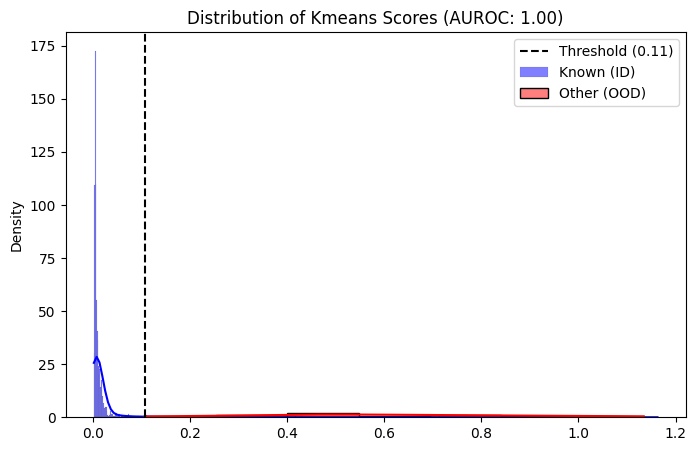


--- Results for Mahalanobis Scores ---
AUROC Score: 0.9976
Optimal Threshold (Youden): 209.5653


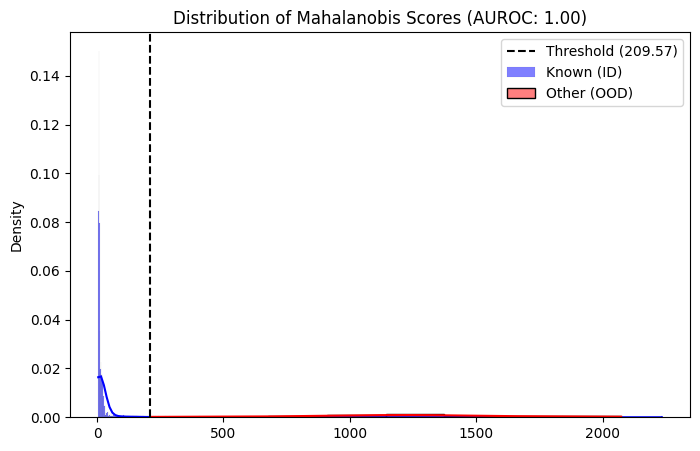


--- Results for Cosine Scores ---
AUROC Score: 0.9961
Optimal Threshold (Youden): 0.0058


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


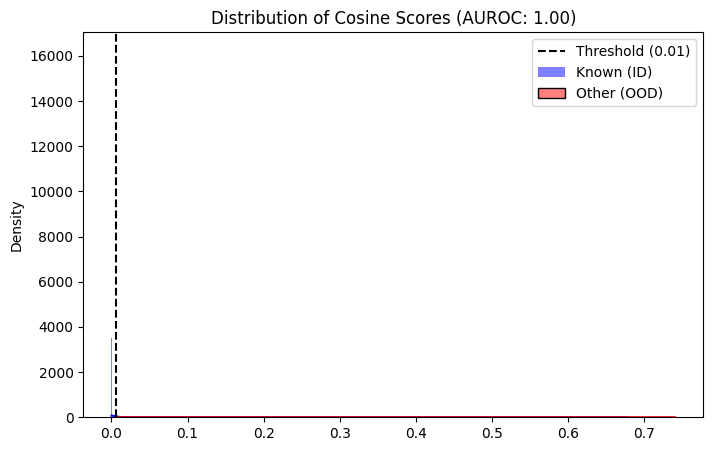

In [45]:
scoring_methods = {
    'kmeans': {'id': kmeans_scores_id, 'ood': kmeans_scores_ood},
    'mahalanobis': {'id': mahalanobis_scores_id, 'ood': mahalanobis_scores_ood},
    'cosine': {'id': cosine_scores_id, 'ood': cosine_scores_ood},
}

# Dictionary to store optimal thresholds for each method
optimal_thresholds = {}

for method_name, scores in scoring_methods.items():
    print(f"\n--- Results for {method_name.capitalize()} Scores ---")

    # 1. Create labels for test data (0 = ID, 1 = OOD)
    y_true_id = np.zeros(len(scores['id']))
    y_true_ood = np.ones(len(scores['ood']))

    y_true = np.concatenate([y_true_id, y_true_ood])
    y_scores = np.concatenate([scores['id'], scores['ood']])

    # 2. Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    auc_score = roc_auc_score(y_true, y_scores)

    print(f"AUROC Score: {auc_score:.4f}")

    # 3. Find optimal threshold (Youden's J Statistic)
    # This is the point that maximizes the sum of sensitivity (TPR) and specificity (1-FPR).
    J = tpr - fpr
    ix = np.argmax(J)
    best_thresh = thresholds[ix]
    optimal_thresholds[method_name] = best_thresh # Store the optimal threshold

    print(f"Optimal Threshold (Youden): {best_thresh:.4f}")

    # Optional: Plot to see how good the separation is
    plt.figure(figsize=(8, 5))
    sns.histplot(scores['id'], color='blue', label='Known (ID)', kde=True, stat="density", alpha=0.5)
    sns.histplot(scores['ood'], color='red', label='Other (OOD)', kde=True, stat="density", alpha=0.5)
    plt.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold ({best_thresh:.2f})')
    plt.title(f"Distribution of {method_name.capitalize()} Scores (AUROC: {auc_score:.2f})")
    plt.legend()
    plt.show()

In [46]:
display(df_validate.head())

,text,label,ood_score_cosine,ood_score_kmeans,ood_score_mahalanobis
0,Prokurist,Other,0.500675,0.999670,1771.482361
1,Solutions Architect,Information Technology,0.092126,0.429228,816.482956
2,Medizintechnik Beratung,Consulting,0.156946,0.542574,1089.727556
3,Director expansión de negocio.,Business Development,0.007127,0.119306,245.132103
4,"APL-ansvarig, samordning",Administrative,0.015993,0.178286,354.877037


### OOD Model Validation on df_validate

This section systematically validates the performance of each OOD detection method (Kmeans, Mahalanobis, and Cosine) on the df_validate dataset. For each method, the following steps are performed:

1.  **Score Calculation**: OOD scores are computed for the validation data using the selected method.
2.  **Prediction Generation**: Based on the previously determined optimal threshold for that method, each validation sample is classified as either 'Known (ID)' or 'OOD (Other)'.
3.  **Performance Evaluation**: A **Classification Report** provides precision, recall, and F1-score for both ID and OOD classes. A **Confusion Matrix** visually summarizes the true positives, true negatives, false positives, and false negatives.
4.  **Score Distribution Visualization**: A histogram shows the distribution of OOD scores for the validation set, with the optimal threshold highlighted to illustrate the separation.
5.  **Example Inspection**: The top 10 examples classified as 'OOD (Other)' and 'Known (ID)' are displayed, allowing for qualitative analysis of the model's decisions.



Validation for Method: Kmeans
Calculating OOD scores for df_validate with method: kmeans...

--- Classification Report (Validation Set) ---
              precision    recall  f1-score   support

  Known (ID)       0.89      0.43      0.58       279
 OOD (Other)       0.67      0.96      0.79       344

    accuracy                           0.72       623
   macro avg       0.78      0.69      0.68       623
weighted avg       0.77      0.72      0.69       623



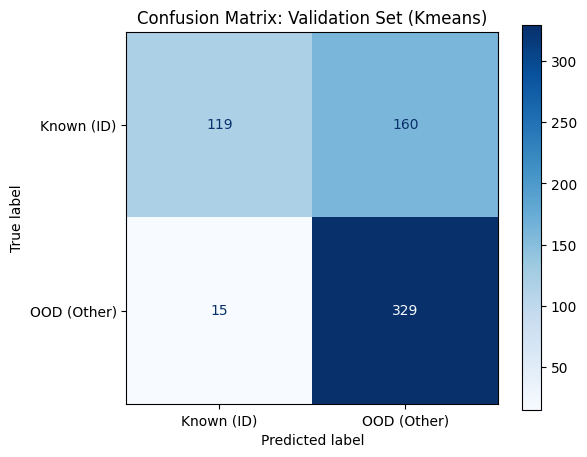

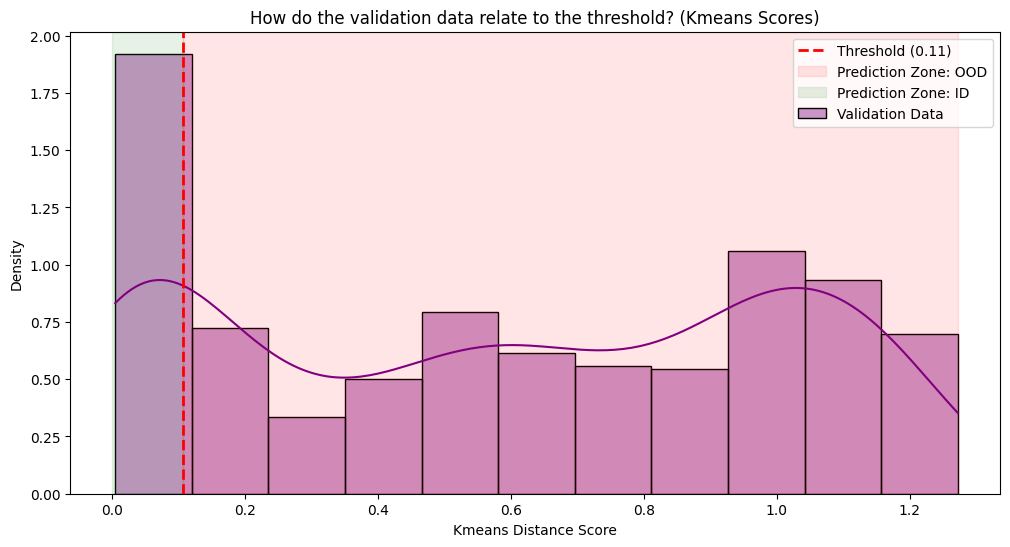


--- Examples: Recognized as OOD (Top Scores) ---


,text,label,ood_score,prediction
117,President,Other,1.272548,OOD (Other)
574,CEO/Founder,Other,1.244028,OOD (Other)
408,Geschäftsführer - CEO,Other,1.235920,OOD (Other)
348,Dozent,Other,1.228933,OOD (Other)
230,Country Manager Czech Republic and Slovakia,Other,1.219700,OOD (Other)
111,Scierie collignon,Other,1.219020,OOD (Other)
161,CEO,Other,1.211149,OOD (Other)
416,CEO,Other,1.211149,OOD (Other)
402,CEO,Other,1.211149,OOD (Other)
474,CEO,Other,1.211149,OOD (Other)



--- Examples: Recognized as ID (Lowest Scores - very confident) ---


,text,label,ood_score,prediction
115,"Executive Director, Marketing Strategy Director",Marketing,0.004379,Known (ID)
420,Head of Sales & Partnerships,Sales,0.004455,Known (ID)
59,Digital Marketing Manager,Marketing,0.004867,Known (ID)
188,Abteilungsdirektor Vertrieb,Sales,0.005023,Known (ID)
180,Digital Project Managerin Marketing,Marketing,0.005033,Known (ID)
308,Head of Marketing Technology (Teamlead),Marketing,0.005081,Known (ID)
548,Director of Sales & SDR Germany,Sales,0.005095,Known (ID)
513,Retail Marketing Management,Marketing,0.005114,Known (ID)
387,Senior Director of Sales & SDR Germany,Sales,0.005263,Known (ID)
250,Chief Sales Officer (CSO),Sales,0.005289,Known (ID)




Validation for Method: Mahalanobis
Calculating OOD scores for df_validate with method: mahalanobis...

--- Classification Report (Validation Set) ---
              precision    recall  f1-score   support

  Known (ID)       0.90      0.48      0.63       279
 OOD (Other)       0.69      0.96      0.80       344

    accuracy                           0.74       623
   macro avg       0.80      0.72      0.72       623
weighted avg       0.79      0.74      0.72       623



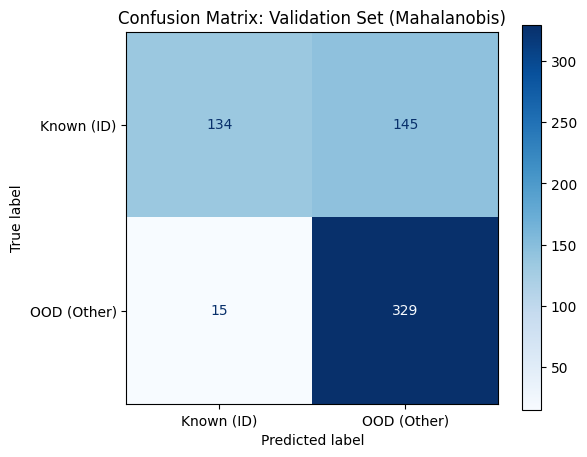

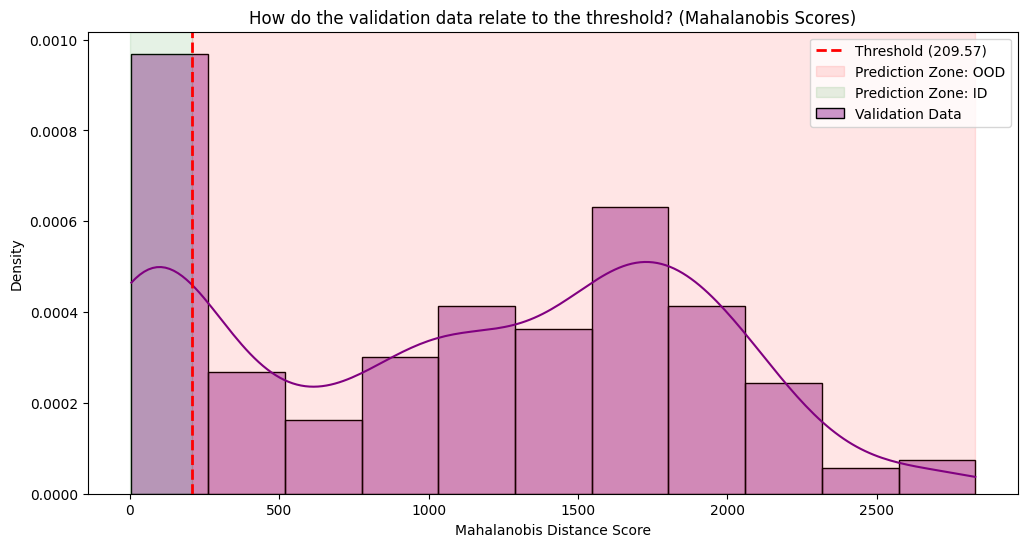


--- Examples: Recognized as OOD (Top Scores) ---


,text,label,ood_score,prediction
611,ExO Sprint Coach,Consulting,2829.870840,OOD (Other)
111,Scierie collignon,Other,2818.823367,OOD (Other)
404,DayTrader,Other,2804.560153,OOD (Other)
230,Country Manager Czech Republic and Slovakia,Other,2744.668205,OOD (Other)
348,Dozent,Other,2738.944959,OOD (Other)
460,Transport Manager,Other,2714.748989,OOD (Other)
9,Set Lighting,Other,2682.224471,OOD (Other)
606,Set Lighting,Other,2682.224471,OOD (Other)
593,Set Lighting,Other,2682.224471,OOD (Other)
573,Set Lighting,Other,2682.224433,OOD (Other)



--- Examples: Recognized as ID (Lowest Scores - very confident) ---


,text,label,ood_score,prediction
300,Director of Sales & Marketing,Sales,5.370136,Known (ID)
226,Sales & Marketing Management,Other,5.610429,Known (ID)
162,Gerente de Comunicação e Marketing,Marketing,5.820119,Known (ID)
59,Digital Marketing Manager,Marketing,5.909825,Known (ID)
188,Abteilungsdirektor Vertrieb,Sales,5.944142,Known (ID)
513,Retail Marketing Management,Marketing,6.151329,Known (ID)
157,Vertriebsdirektor,Sales,6.419123,Known (ID)
422,Vertriebsleiter,Sales,6.469360,Known (ID)
242,Vertriebsingenieur,Sales,6.516374,Known (ID)
180,Digital Project Managerin Marketing,Marketing,6.551372,Known (ID)




Validation for Method: Cosine
Calculating OOD scores for df_validate with method: cosine...

--- Classification Report (Validation Set) ---
              precision    recall  f1-score   support

  Known (ID)       0.88      0.38      0.53       279
 OOD (Other)       0.66      0.96      0.78       344

    accuracy                           0.70       623
   macro avg       0.77      0.67      0.65       623
weighted avg       0.75      0.70      0.67       623



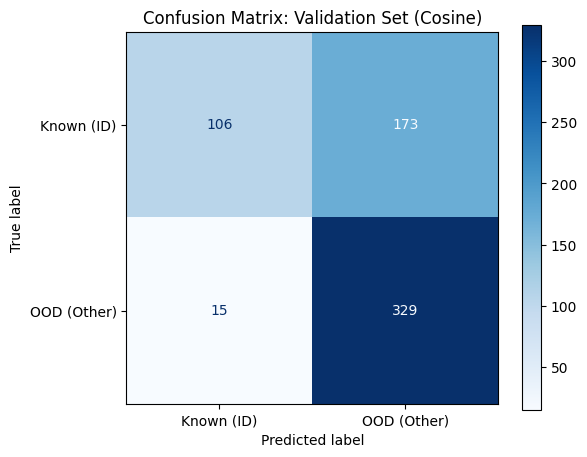

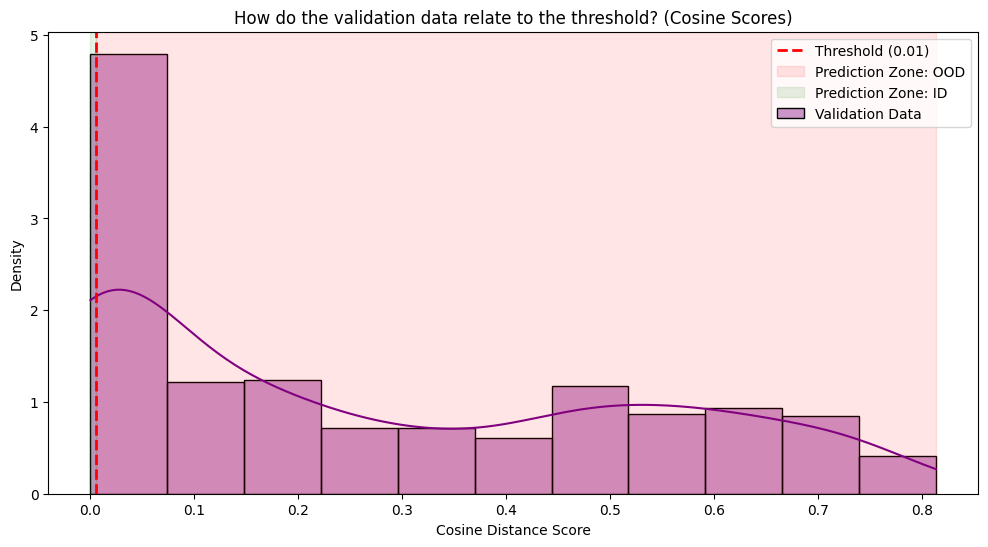


--- Examples: Recognized as OOD (Top Scores) ---


,text,label,ood_score,prediction
348,Dozent,Other,0.813664,OOD (Other)
117,President,Other,0.811883,OOD (Other)
574,CEO/Founder,Other,0.786986,OOD (Other)
512,Werteorientiertes Führungskräftetraining,Consulting,0.781457,OOD (Other)
47,Gesellschafter,Other,0.772196,OOD (Other)
563,In non compete phase,Other,0.769923,OOD (Other)
408,Geschäftsführer - CEO,Other,0.764470,OOD (Other)
496,"Regionalbeauftragter Club Sachsen, Thüringen, ...",Other,0.759303,OOD (Other)
611,ExO Sprint Coach,Consulting,0.757973,OOD (Other)
354,Responsable de salle,Administrative,0.757742,OOD (Other)



--- Examples: Recognized as ID (Lowest Scores - very confident) ---


,text,label,ood_score,prediction
285,Head of Sales DACH,Sales,0.000009,Known (ID)
180,Digital Project Managerin Marketing,Marketing,0.000011,Known (ID)
452,Automotive Sales Manager,Sales,0.000011,Known (ID)
305,"Vice President, National Sales Manager",Sales,0.000012,Known (ID)
162,Gerente de Comunicação e Marketing,Marketing,0.000013,Known (ID)
420,Head of Sales & Partnerships,Sales,0.000017,Known (ID)
250,Chief Sales Officer (CSO),Sales,0.000017,Known (ID)
300,Director of Sales & Marketing,Sales,0.000018,Known (ID)
548,Director of Sales & SDR Germany,Sales,0.000019,Known (ID)
443,"Regional Sales Manager, Central European Region",Sales,0.000019,Known (ID)


In [47]:
# List of scoring methods to validate
validation_methods_to_run = ['kmeans', 'mahalanobis', 'cosine']

for VALIDATION_METHOD in validation_methods_to_run:
    print(f"\n\n=======================================================")
    print(f"Validation for Method: {VALIDATION_METHOD.capitalize()}")
    print(f"=======================================================")

    # 1. Calculate scores for validation data
    print(f"Calculating OOD scores for df_validate with method: {VALIDATION_METHOD}...")
    val_scores = get_ood_scores(val_embeddings, VALIDATION_METHOD )

    # Retrieve the best threshold for the selected method
    best_thresh_for_validation = optimal_thresholds.get(VALIDATION_METHOD)

    if best_thresh_for_validation is None:
        print(f"Error: No optimal threshold found for method '{VALIDATION_METHOD}'. Please run the previous cell first to calculate thresholds.")
        continue # Skip to the next method if threshold is missing

    # Write results to a copy
    df_val_results = df_validate.copy()
    df_val_results['ood_score'] = val_scores

    # 2. Prediction based on your threshold-
    # Everything above the threshold is "OOD" (i.e., "Other"), everything below is "ID" (Known)
    df_val_results['prediction'] = df_val_results['ood_score'].apply(
        lambda x: 'OOD (Other)' if x > best_thresh_for_validation else 'Known (ID)'
    )

    # Calculate uncertainty (distance to threshold)
    df_val_results['distance_to_threshold'] = df_val_results['ood_score'] - best_thresh_for_validation

    # 3. Ground Truth Comparison (if labels are available)
    # We assume your label 'Other' is the target for OOD.
    LABEL_COL = 'label'
    OOD_CLASS_NAME = 'Other' # As it appears in the dataset

    if LABEL_COL in df_val_results.columns:
        # Create binary labels for evaluation (1 = OOD, 0 = ID)
        y_true_val = (df_val_results[LABEL_COL] == OOD_CLASS_NAME).astype(int)
        y_pred_val = (df_val_results['prediction'] == 'OOD (Other)').astype(int)

        print("\n--- Classification Report (Validation Set) ---")
        print(classification_report(y_true_val, y_pred_val, target_names=['Known (ID)', 'OOD (Other)']))

        # Confusion Matrix Plot
        cm = confusion_matrix(y_true_val, y_pred_val)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Known (ID)', 'OOD (Other)'])
        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(cmap='Blues', ax=ax)
        plt.title(f"Confusion Matrix: Validation Set ({VALIDATION_METHOD.capitalize()})")
        plt.show()

    # 4. Visualization of Score Distribution-
    plt.figure(figsize=(12, 6))

    # Histogram of Validation Scores
    sns.histplot(
        df_val_results['ood_score'],
        color='purple',
        label='Validation Data',
        kde=True,
        stat="density",
        alpha=0.4
    )

    # Threshold Line
    plt.axvline(best_thresh_for_validation, color='red', linestyle='--', linewidth=2, label=f'Threshold ({best_thresh_for_validation:.2f})')

    # Color areas
    plt.axvspan(best_thresh_for_validation, df_val_results['ood_score'].max(), color='red', alpha=0.1, label='Prediction Zone: OOD')
    plt.axvspan(0, best_thresh_for_validation, color='green', alpha=0.1, label='Prediction Zone: ID')

    plt.title(f"How do the validation data relate to the threshold? ({VALIDATION_METHOD.capitalize()} Scores)")
    plt.xlabel(f"{VALIDATION_METHOD.capitalize()} Distance Score")
    plt.legend()
    plt.show()

    print("\n--- Examples: Recognized as OOD (Top Scores) ---")
    ood_detected = df_val_results[df_val_results['prediction'] == 'OOD (Other)'].sort_values('ood_score', ascending=False)
    display(ood_detected[['text', LABEL_COL, 'ood_score', 'prediction']].head(10))

    print("\n--- Examples: Recognized as ID (Lowest Scores - very confident) ---")
    id_detected = df_val_results[df_val_results['prediction'] == 'Known (ID)'].sort_values('ood_score', ascending=True)
    display(id_detected[['text', LABEL_COL, 'ood_score', 'prediction']].head(10))